# Project 1 – Decision Trees and Random Forests

In [1]:
# Reload all modules without having to restart the kernel
%load_ext autoreload
%autoreload 2

# Imports
import numpy as np
import random
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold

# My implementations
from decision_tree import DecisionTree
from random_forest import RandomForest

# Base seed explained in report
seed = 0
np.random.seed(seed)
random.seed(seed)

## Dataset

Do data loading, exploration and preprocessing as you see fit.

Here is some code to load the dataset to get you started.

In [2]:
# Load dataset
data = np.genfromtxt("letters.csv", delimiter=",", dtype=float, names=True)

feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]

X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)

print(f"Feature column names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


Feature column names: ['xbox', 'ybox', 'width', 'high', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'xege', 'xegvy', 'yege', 'yegvx']
Target column name: label
X shape: (2000, 16)
y shape: (2000,)


In [3]:
#DECISION TREES

    #Train/validation split
    #First split:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=0.3, random_state=seed, shuffle=True, stratify=y)   #train = 70%, VALIDATION/test = 30%
X_test, X_val, y_test, y_val = train_test_split(X_val_test, y_val_test, test_size=0.5, shuffle=True, stratify=y_val_test)   #THIS SPLITS THE DATA INTO 15% TEST 15% VALIDATION
    #15% validation 
    #15% test

#StratifiedKFold ensures class proportions are preserved
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)   #explained in report
    #prepares 5-fold cross validation
    #each fold keeps the same proportion in each class
    #shuffle = true the seed ensures that it can be reproduced


dt_max_depths = [None, 4, 6, 8, 10, 12, 14]     #Decision Tree hyperparameters to test
dt_criteria  = ["gini", "entropy"]

dt_hyper_parameters_combo = [
    {"max_depth": d, "criterion": c}
    for d in dt_max_depths for c in dt_criteria
]

X_train_val = np.concatenate([X_train, X_val], axis=0)  #creating test+validation DATA to be split later split up
y_train_val = np.concatenate([y_train, y_val], axis=0)

all_scores = []     #store cross validation results for each hyper parameter combination

for hyper_param in dt_hyper_parameters_combo:   #this loop says that for each hyperpar it prepares lists to collect the results across folds 
    fold_accuracy = []
    fold_f1 = []

    for train_index, val_index in cv.split(X_train_val, y_train_val):   #generates 5 pairs of index arrays then for each of these pairs:
        X_train_fold, X_val_fold = X_train_val[train_index], X_train_val[val_index] #X train and X val is created      
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index] #Xy train and y val is created     

        model = DecisionTree( #train DT with current hyperparameters defined in outer loop
            max_depth=hyper_param["max_depth"], 
            criterion=hyper_param["criterion"],
        )
        model.fit(X_train_fold, y_train_fold) #fits 
        y_predict = model.predict(X_val_fold) #predict

        fold_accuracy.append(accuracy_score(y_val_fold, y_predict)) 
        fold_f1.append(f1_score(y_val_fold, y_predict, average="macro", zero_division=0)) #zero devision just to be sure that if a rare class is present and isnt in the validation set, precision and recall wont have a devide by 0 error

    # Compute means for this hyperparam combo
    cv_acc = float(np.mean(fold_accuracy))
    cv_macroF1 = float(np.mean(fold_f1))

    all_scores.append({                 
        "cv_acc": cv_acc,                           #we have 16 of these
        "cv_macroF1": cv_macroF1,
        "max_depth": hyper_param["max_depth"],
        "criterion": hyper_param["criterion"],
    })

# Pick best by accuracy, tie-break by macro-F1
best_score = all_scores[0] #we use all_scores[0] just so we have something to compare agenst
best_idx = 0
for i, row in enumerate(all_scores[1:], start=1):
    if (row["cv_acc"], row["cv_macroF1"]) > (best_score["cv_acc"], best_score["cv_macroF1"]):
        best_score = row
        best_idx = i

print("Best Decision Tree:",
      f"acc={best_score['cv_acc']:.4f}, macroF1={best_score['cv_macroF1']:.4f},",
      f"max_depth={best_score['max_depth']}, criterion={best_score['criterion']}")
    


Best Decision Tree: acc=0.9088, macroF1=0.9093, max_depth=10, criterion=entropy


*Random Forest*

In [4]:
#RANDOMFOREST:
#same implementation as DT
#Asside from the hyperparameters to test
#hyperparameters to test
rf_n_estimators = [5,10,20] #explained in report why these hyperparameters
rf_max_depts = [None,5,10]
rf_criteria = ["gini","entropy"]
rf_max_features = ["sqrt","log2",None]

rf_hyper_parameters_combo = [
    {"n_estimators": n, "max_depth": d, "criterion": c, "max_features": mf}
    for n in rf_n_estimators
    for d in rf_max_depts
    for c in rf_criteria
    for mf in rf_max_features]

all_rf_scores = []
for hyper_param in rf_hyper_parameters_combo:
    fold_accuracy = []
    fold_f1 = []

    for train_index, val_index in cv.split(X_train_val, y_train_val):
        X_train_fold, X_val_fold = X_train_val[train_index], X_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]

        model = RandomForest(
            n_estimators=hyper_param["n_estimators"],
            max_depth=hyper_param["max_depth"], 
            criterion=hyper_param["criterion"],
            max_features=hyper_param["max_features"]
        )
        model.fit(X_train_fold, y_train_fold)
        y_predict = model.predict(X_val_fold)

        fold_accuracy.append(accuracy_score(y_val_fold, y_predict))
        fold_f1.append(f1_score(y_val_fold, y_predict, average="macro", zero_division=0))

    # Compute means for this hyperparam combo
    cv_acc = float(np.mean(fold_accuracy))
    cv_macroF1 = float(np.mean(fold_f1))

    all_rf_scores.append({
        "cv_acc": cv_acc,
        "cv_macroF1": cv_macroF1,                      #we have 54 hyperparameter combos
        "n_estimators": hyper_param["n_estimators"],
        "max_depth": hyper_param["max_depth"],
        "criterion": hyper_param["criterion"],
        "max_features": hyper_param["max_features"],
    })

# Pick best by accuracy, tie-break by macro-F1
best_rf_score = all_rf_scores[0]
for row in all_rf_scores[1:]:
    if (row["cv_acc"], row["cv_macroF1"]) > (best_rf_score["cv_acc"], best_rf_score["cv_macroF1"]):
        best_rf_score = row

print("Best Random Forest:",
      f"acc={best_rf_score['cv_acc']:.4f}, macroF1={best_rf_score['cv_macroF1']:.4f},",
      f"n_estimators={best_rf_score['n_estimators']},",
      f"max_depth={best_rf_score['max_depth']},",
      f"criterion={best_rf_score['criterion']},",
      f"max_features={best_rf_score['max_features']}")

Best Random Forest: acc=0.9665, macroF1=0.9667, n_estimators=20, max_depth=None, criterion=entropy, max_features=log2


**in order for us to be able to compare our models to sklearn and for it to be fair we have to be able to have the same type of training for the model** Hence:

In [5]:
#SKLEARNS DECISION TREES
# same implementation of our DT

dt_max_depths = [None, 4, 6, 8, 10, 12, 14]
dt_criteria  = ["gini", "entropy"]

dt_hyper_parameters_combo = [
    {"max_depth": d, "criterion": c}
    for d in dt_max_depths for c in dt_criteria
]

all_scores_sklearn = []


for hyper_param in dt_hyper_parameters_combo:
    fold_accuracy = []
    fold_f1 = []


    for train_index, val_index in cv.split(X_train_val, y_train_val):
        X_train_fold, X_val_fold = X_train_val[train_index], X_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]

        model = DecisionTreeClassifier( 
            max_depth=hyper_param["max_depth"], 
            criterion=hyper_param["criterion"],
        )
        model.fit(X_train_fold, y_train_fold) #fits 
        y_predict = model.predict(X_val_fold) #predict

        fold_accuracy.append(accuracy_score(y_val_fold, y_predict)) 
        fold_f1.append(f1_score(y_val_fold, y_predict, average="macro", zero_division=0)) 

    cv_acc = float(np.mean(fold_accuracy))
    cv_macroF1 = float(np.mean(fold_f1))

    all_scores_sklearn.append({                 
        "cv_acc": cv_acc,                          
        "cv_macroF1": cv_macroF1,
        "max_depth": hyper_param["max_depth"],
        "criterion": hyper_param["criterion"],
    })

best_score_sklearn = all_scores_sklearn[0] 
best_idx = 0
for i, row in enumerate(all_scores_sklearn[1:], start=1):
    if (row["cv_acc"], row["cv_macroF1"]) > (best_score_sklearn["cv_acc"], best_score_sklearn["cv_macroF1"]):
        best_score_sklearn = row
        best_idx = i

print("Best SKLEARN Decision Tree:",
      f"acc={best_score_sklearn['cv_acc']:.4f}, macroF1={best_score_sklearn['cv_macroF1']:.4f},",
      f"max_depth={best_score_sklearn['max_depth']}, criterion={best_score_sklearn['criterion']}")
    

Best SKLEARN Decision Tree: acc=0.9206, macroF1=0.9209, max_depth=14, criterion=entropy


**MAKE THE SAME THING WITH SKLEARN RANDOM FOREST**

In [6]:
#SKLEARN RANDOMFOREST hyperparameters to test
rf_n_estimators = [5,10,20] 
rf_max_depts = [None,5,10]
rf_criteria = ["gini","entropy"]
rf_max_features = ["sqrt","log2",None] 

rf_hyper_parameters_combo = [
    {"n_estimators": n, "max_depth": d, "criterion": c, "max_features": mf}
    for n in rf_n_estimators
    for d in rf_max_depts
    for c in rf_criteria
    for mf in rf_max_features]

all_rf_scores_sklearn = []
for hyper_param in rf_hyper_parameters_combo:
    fold_accuracy = []
    fold_f1 = []

    for train_index, val_index in cv.split(X_train_val, y_train_val):
        X_train_fold, X_val_fold = X_train_val[train_index], X_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]

        model = RandomForestClassifier(
            n_estimators=hyper_param["n_estimators"],
            max_depth=hyper_param["max_depth"], 
            criterion=hyper_param["criterion"],
            max_features=hyper_param["max_features"]
        )
        model.fit(X_train_fold, y_train_fold)
        y_predict = model.predict(X_val_fold)

        fold_accuracy.append(accuracy_score(y_val_fold, y_predict)) 
        fold_f1.append(f1_score(y_val_fold, y_predict, average="macro", zero_division=0))

    # Compute means for this hyperparam combo
    cv_acc = float(np.mean(fold_accuracy))
    cv_macroF1 = float(np.mean(fold_f1))

    all_rf_scores_sklearn.append({
        "cv_acc": cv_acc,
        "cv_macroF1": cv_macroF1,
        "n_estimators": hyper_param["n_estimators"],
        "max_depth": hyper_param["max_depth"],
        "criterion": hyper_param["criterion"],
        "max_features": hyper_param["max_features"],
    })

# Pick best by accuracy, tie-break by macro-F1
best_rf_score_sklearn = all_rf_scores_sklearn[0]
for row in all_rf_scores_sklearn[1:]:
    if (row["cv_acc"], row["cv_macroF1"]) > (best_rf_score_sklearn["cv_acc"], best_rf_score_sklearn["cv_macroF1"]):
        best_rf_score_sklearn = row

print("Best Sklearn Random Forest:",
      f"acc={best_rf_score_sklearn['cv_acc']:.4f}, macroF1={best_rf_score_sklearn['cv_macroF1']:.4f},",
      f"n_estimators={best_rf_score_sklearn['n_estimators']},",
      f"max_depth={best_rf_score_sklearn['max_depth']},",
      f"criterion={best_rf_score_sklearn['criterion']},",
      f"max_features={best_rf_score_sklearn['max_features']}")

Best Sklearn Random Forest: acc=0.9624, macroF1=0.9628, n_estimators=20, max_depth=10, criterion=entropy, max_features=sqrt


**now we can compare all 4 models because they have been trained in the same mannor**

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Getting out the test data from all the models, they all have the same test data due to the seed being the same

#3.2 Model Evaluation

#putting the training and validation data together
X_train_validationset = np.concatenate([X_train, X_val], axis =0) 
y_train_validationset = np.concatenate([y_train, y_val], axis =0) 

#_____#DT final implementation______#
dt_final_model = DecisionTree(max_depth=best_score["max_depth"],criterion=best_score["criterion"])
dt_final_model.fit(X_train_validationset,y_train_validationset)
dt_y_pred = dt_final_model.predict(X_test)

dt_final_accuracy = accuracy_score(y_test,dt_y_pred)
print("Our Decision Tree algorithm Accuracy:",dt_final_accuracy)

#_____#RF final implementation______#
rf_final_model = RandomForest(
    n_estimators = best_rf_score["n_estimators"],
    max_depth = best_rf_score["max_depth"],
    criterion = best_rf_score["criterion"],
    max_features = best_rf_score["max_features"]
)

rf_final_model.fit(X_train_validationset,y_train_validationset)
rf_y_pred = rf_final_model.predict(X_test)

rf_final_accuracy = accuracy_score(y_test,rf_y_pred)
print("Our Random Forest Tree alogirhtm Accuracy:",rf_final_accuracy)

#____SKlearn DT________#
sk_dt = DecisionTreeClassifier(max_depth = best_score_sklearn['max_depth'], criterion = best_score_sklearn["criterion"], random_state=seed)
sk_dt.fit(X_train_validationset, y_train_validationset)
sk_y_pred = sk_dt.predict(X_test)
print("For the Sklearn Decision Tree the Test Acc:", accuracy_score(y_test, sk_y_pred))

#____SKlearn RF________#
sk_rf = RandomForestClassifier(n_estimators = best_rf_score_sklearn['n_estimators'],
                                max_depth=best_rf_score_sklearn['max_depth'], 
                                criterion=best_rf_score_sklearn['criterion'], 
                                max_features=best_rf_score_sklearn['max_features'], 
                                random_state=seed)
sk_rf.fit(X_train_validationset, y_train_validationset)
sk_y_pred = sk_rf.predict(X_test)
print("Sklearn Random Forest Test Acc:", accuracy_score(y_test, sk_y_pred))




Our Decision Tree algorithm Accuracy: 0.9433333333333334
Our Random Forest Tree alogirhtm Accuracy: 0.9766666666666667
For the Sklearn Decision Tree the Test Acc: 0.94
Sklearn Random Forest Test Acc: 0.97


**part 4: Feature Importance**

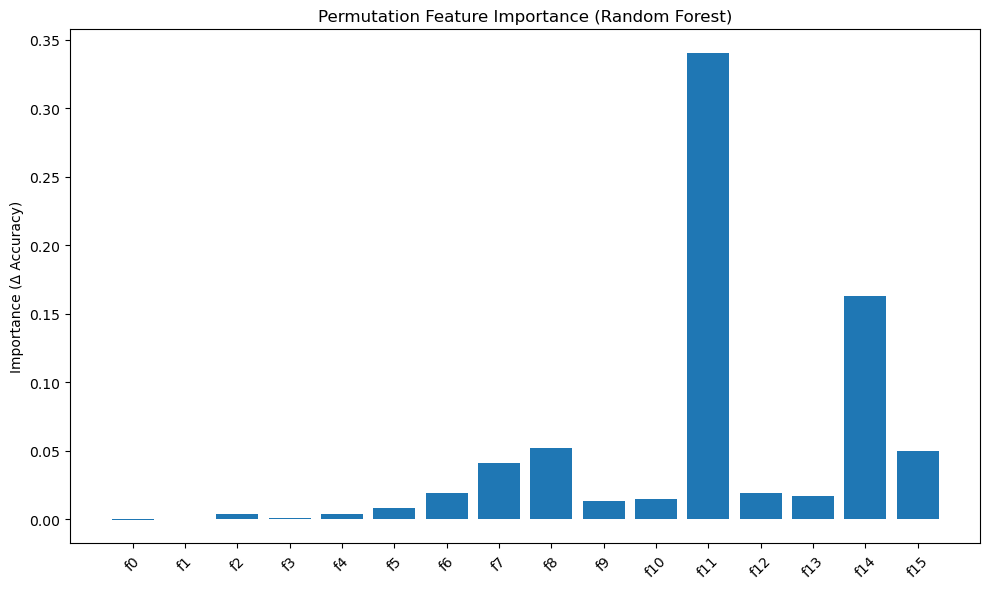

Feature f0: -0.0004
Feature f1: -0.0001
Feature f2: 0.0042
Feature f3: 0.0011
Feature f4: 0.0041
Feature f5: 0.0082
Feature f6: 0.0196
Feature f7: 0.0411
Feature f8: 0.0519
Feature f9: 0.0134
Feature f10: 0.0147
Feature f11: 0.3407
Feature f12: 0.0189
Feature f13: 0.0167
Feature f14: 0.1629
Feature f15: 0.0499


In [8]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def permutation_importance(model, X, y, metric=accuracy_score, n_repeats=30, seed=seed):
    
    randomnumgen = np.random.default_rng(seed)  #creates a random num generation from our seed so its reproducible

    base_score = metric(y, model.predict(X))    #evaluates trained model on unshuffeled test data (accuracy)
    n_features = X.shape[1]

    importantscores = np.zeros(n_features) 

  
    for featnum in range(n_features):   #loops # of elements in n_feature times
        scores = []

        for feature in range(n_repeats): #creates copy shuffles and predicts, n_repeats times
            X_permuted = X.copy() #makes a new instance of X
            randomnumgen.shuffle(X_permuted[:, featnum]) #shuffles the values of feature(#featnum)
            score = metric(y, model.predict(X_permuted))#computes the model performance
            scores.append(score)#stores score

        importantscores[featnum] = base_score - np.mean(scores) #takes the mean(average) accuracy from the base see if it drops

    # Step 6: return all importances
    return importantscores


feature_importance_score = permutation_importance(rf_final_model,X_test, y_test, metric=accuracy_score, n_repeats=30, seed=seed )

#plotting the data
plt.figure(figsize=(10,6))
plt.bar(range(len(feature_importance_score)), feature_importance_score, align="center")
plt.xticks(range(len(feature_importance_score)), [f"f{i}" for i in range(len(feature_importance_score))], rotation=45)
plt.ylabel("Importance (Δ Accuracy)")
plt.title("Permutation Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

#printing the actual numbers
for i, score in enumerate(feature_importance_score):
    print(f"Feature f{i}: {score:.4f}")
